# Distance to TLS and bronchi — visualization (02b)

**Pinned Environment:** [`conda_envs/space2_20250604.yml`](../conda_envs/space2_20250604.yml)  

In [1]:
from pathlib import Path
import sys
import os
import time
import warnings
import re
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata
import scanpy as sc
import squidpy as sq


import scipy
from scipy.spatial import distance_matrix
from scipy.spatial.distance import cdist
from scipy import stats
import scipy.ndimage as ndi
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks

from shapely.geometry import Point

from shapely.geometry import MultiPolygon
from alphashape import alphashape
from alphashape import optimizealpha
import geopandas as gpd

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer

import pickle
import joblib

import random
import matplotlib.colors as mcolors

import matplotlib as mpl
mpl.rcParams['axes.titlesize'] = 24
mpl.rcParams['pdf.fonttype'] = 42

import warnings
warnings.simplefilter(action='ignore', category=Warning)

sys.version_info

sys.version_info(major=3, minor=12, micro=2, releaselevel='final', serial=0)

## Local file info

In [2]:
sys.path.append(str(Path.cwd().resolve().parents[0]))

from config.paths import BASE_OUTDIR, INPUTS_DIR, FUNCTIONS_DIR

inputs_dir = INPUTS_DIR
dist_out_dir = os.path.join(BASE_OUTDIR, "downstream_analysis/distance")


plot_out_dir = os.path.join(dist_out_dir, 'plots')

print(inputs_dir)
print(dist_out_dir)

/home/workspace/spatial_tls_manuscript/inputs
/home/workspace/spatial_mouse_lung_outputs/downstream_analysis/distance


In [3]:
import importlib
if str(FUNCTIONS_DIR) not in sys.path:
    sys.path.append(str(FUNCTIONS_DIR))

import plotting_utils as pu
import de_utils as du

In [4]:
importlib.reload(du)

<module 'de_utils' from '/home/workspace/spatial_tls_manuscript/utils/de_utils.py'>

## Load adata

In [5]:
adata = sc.read_h5ad(os.path.join(dist_out_dir,'adata_distance_zones_structure_tls_dist_categories.h5ad'))

## Load palettes

In [6]:
with open(os.path.join(inputs_dir, '20250519_celltype_palette_mapped.pkl'), 'rb') as f:
    celltype_palette_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, '20250520_celltype_palette_coarse_mapped.pkl'), 'rb') as f:
    celltype_palette_coarse_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, '20250520_celltype_palette_coarser_mapped.pkl'), 'rb') as f:
    celltype_palette_coarser_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, '20250521_zone_consol_palette_mapped.pkl'), 'rb') as f:
    zone_consol_palette_mapped = pickle.load(f)

In [7]:
import matplotlib.colors as clr
import colorcet

zissou = [
    "#3A9AB2",
    "#6FB2C1",
    "#91BAB6",
    "#A5C2A3",
    "#BDC881",
    "#DCCB4E",
    "#E3B710",
    "#E79805",
    "#EC7A05",
    "#EF5703",
    "#F11B00",
]

colormap = clr.LinearSegmentedColormap.from_list("Zissou", zissou)
colormap_r = clr.LinearSegmentedColormap.from_list("Zissou", zissou[::-1])

## Ligand–receptor spatial co-localization (Jensen-Shannon distance)
- For one receptor and its ligand(s), compare the spatial distribution of ligand expression to the distribution of receptor expression within each cell type.
- JS distance over a 50 um grid of summed expression per bin; 0 = co-localized (bright).


In [68]:
from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance


def _gene_expr(ad, gene, layer=None):
    """1D expression vector for a single gene (handles sparse / layer)."""
    X = ad[:, gene].layers[layer] if layer is not None else ad[:, gene].X
    return (X.toarray() if hasattr(X, 'toarray') else np.asarray(X)).ravel()


def _spatial_field(x, y, w, xedges, yedges, sigma):
    """2D summed-expression grid per bin, optionally Gaussian-smoothed.
    This is the binned data that (after normalization) feeds the JS distance."""
    w = np.clip(np.nan_to_num(w), 0, None)
    H, _, _ = np.histogram2d(x, y, bins=[xedges, yedges], weights=w)
    if sigma:
        H = gaussian_filter(H, sigma=sigma)
    return H


def _normalize(H):
    """Flatten a 2D field to a probability vector (sum 1); None if empty."""
    if H is None:
        return None
    s = H.sum()
    return None if s <= 0 else (H / s).ravel()


def _wasserstein2d_sliced(Pgrid, Qgrid, xcenters, ycenters, n_proj=48, seed=0):
    """Sliced 2D Wasserstein distance between two non-negative grids (same shape).
    Projects bin centers onto random directions and averages the 1D Wasserstein
    distance. Returned in the units of the bin coordinates (um). Unlike JS, this
    accounts for how FAR apart the mass is. None if either grid has no mass."""
    if Pgrid is None or Qgrid is None:
        return None
    p, q = Pgrid.ravel().astype(float), Qgrid.ravel().astype(float)
    if p.sum() <= 0 or q.sum() <= 0:
        return None
    XX, YY = np.meshgrid(xcenters, ycenters, indexing='ij')
    coords = np.column_stack([XX.ravel(), YY.ravel()])
    keep = (p > 0) | (q > 0)                 # only bins with mass (speed)
    coords, p, q = coords[keep], p[keep], q[keep]
    rng = np.random.default_rng(seed)
    thetas = rng.normal(size=(n_proj, 2))
    thetas /= np.linalg.norm(thetas, axis=1, keepdims=True)
    dists = [wasserstein_distance(coords @ t, coords @ t, p, q) for t in thetas]
    return float(np.mean(dists))


def plot_binned_fields(fields, receptor, ligands, celltypes,
                       ncols=4, panel_size=2.2, cmap='viridis'):
    """Diagnostic: spatial maps of the binned summed expression that go into the
    JS calculation -- one panel per ligand (all cells) and one per receptor x
    cell type. Each panel is scaled to its own 99th percentile."""
    xedges, yedges = fields['xedges'], fields['yedges']
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    panels = [(f'ligand: {lig}', fields['ligands'][lig]) for lig in ligands]
    panels += [(f'{receptor} in {ct}', fields['receptors'][ct]) for ct in celltypes]

    n = len(panels)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, dpi=150, squeeze=False,
                             figsize=(panel_size * ncols, panel_size * nrows))
    for ax in axes.ravel():
        ax.axis('off')
    for k, (title, grid) in enumerate(panels):
        ax = axes.ravel()[k]
        ax.axis('on')
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(title, fontsize=7)
        if grid is None or not np.any(grid > 0):
            ax.text(0.5, 0.5, 'no signal', ha='center', va='center',
                    fontsize=8, transform=ax.transAxes)
            continue
        vmax = np.percentile(grid[grid > 0], 99)
        ax.imshow(grid.T, origin='lower', extent=extent, aspect='equal',
                  cmap=cmap, vmax=vmax)
    fig.suptitle(f"Binned summed expression (JS inputs) — {fields['sample']}",
                 fontsize=10)
    fig.tight_layout()
    return fig


def plot_ligand_receptor_js_proximity(
    adata, receptor, ligands, celltype_col, celltypes,
    sample='HDM_day3', sample_col='sample_label',
    bin_size_um=50, smooth_sigma=1.0,
    x_coord='x_centroid', y_coord='y_centroid',
    layer=None, cmap='viridis_r', annotate=True, figsize=None,
    show_binned=False, vmin=None, vmax=None, autoscale=False,
    metric='js', n_proj=48, wass_seed=0,
):
    """
    Spatial co-localization of ligand-producing cells and receptor+ cells, per
    cell type. One receptor (-> top bar) and its ligand(s) (-> rows) vs. an
    ordered list of cell types (-> columns).

    Each heatmap cell compares (a) the spatial distribution of the ligand's
    expression over ALL cells and (b) the spatial distribution of `receptor`
    expression within that column's cell type. Both are sum-per-bin histograms
    on a shared `bin_size_um` grid over (x_coord, y_coord), Gaussian-smoothed.

    metric : 'js' (default) or 'wasserstein'
        'js'          -> Jensen-Shannon distance in [0, 1]; bin-independent
                         (ignores how far apart non-overlapping bins are; the
                         smoothing is what gives it any neighbor-awareness).
        'wasserstein' -> sliced 2D Wasserstein distance in um; accounts for how
                         far mass must move, so "near misses" score lower than
                         "far misses". Unbounded; vmax auto-set from the data.
    Both follow 0 = co-localized; with cmap='viridis_r', bright = co-localized.

    Set show_binned=True to also plot the binned summed-expression maps. Returns
    (fig, M, fields): M = [ligand x celltype] distance matrix; fields = dict of
    the 2D binned grids (+ grid edges) for replotting.
    """
    if metric not in ('js', 'wasserstein'):
        raise ValueError("metric must be 'js' or 'wasserstein'")
    missing = [g for g in [receptor, *ligands] if g not in adata.var_names]
    if missing:
        raise ValueError(f'genes not in adata.var_names: {missing}')

    ad = adata[adata.obs[sample_col] == sample]
    x_all = ad.obs[x_coord].to_numpy(dtype=float)
    y_all = ad.obs[y_coord].to_numpy(dtype=float)

    # shared grid edges from all cells in the sample
    xedges = np.arange(x_all.min(), x_all.max() + bin_size_um, bin_size_um)
    yedges = np.arange(y_all.min(), y_all.max() + bin_size_um, bin_size_um)
    xcenters = (xedges[:-1] + xedges[1:]) / 2
    ycenters = (yedges[:-1] + yedges[1:]) / 2

    # ligand fields (all cells), one per row
    lig_fields = {lig: _spatial_field(x_all, y_all, _gene_expr(ad, lig, layer),
                                      xedges, yedges, smooth_sigma)
                  for lig in ligands}

    # receptor field per cell type (column) + mean receptor expression
    rec_all = _gene_expr(ad, receptor, layer)
    rec_fields, mean_recep = {}, {}
    for ct in celltypes:
        mask = (ad.obs[celltype_col] == ct).to_numpy()
        if mask.sum() == 0:
            rec_fields[ct], mean_recep[ct] = None, np.nan
            continue
        rec_fields[ct] = _spatial_field(x_all[mask], y_all[mask], rec_all[mask],
                                        xedges, yedges, smooth_sigma)
        mean_recep[ct] = rec_all[mask].mean()

    fields = {'ligands': lig_fields, 'receptors': rec_fields,
              'xedges': xedges, 'yedges': yedges,
              'bin_size_um': bin_size_um, 'sample': sample}

    # distance matrix [ligand x celltype]
    P = {lig: _normalize(lig_fields[lig]) for lig in ligands}
    Q = {ct: _normalize(rec_fields[ct]) for ct in celltypes}
    M = np.full((len(ligands), len(celltypes)), np.nan)
    for i, lig in enumerate(ligands):
        for j, ct in enumerate(celltypes):
            if metric == 'js':
                if P[lig] is not None and Q[ct] is not None:
                    M[i, j] = jensenshannon(P[lig], Q[ct], base=2)
            else:  # wasserstein
                d = _wasserstein2d_sliced(lig_fields[lig], rec_fields[ct],
                                          xcenters, ycenters,
                                          n_proj=n_proj, seed=wass_seed)
                if d is not None:
                    M[i, j] = d

    # color range / labels depend on metric
    finite = M[np.isfinite(M)]
    if autoscale:
        # stretch the colormap over the actual min..max of the computed values
        vmin = float(finite.min()) if finite.size else 0.0
        vmax = float(finite.max()) if finite.size else 1.0
        if vmax <= vmin:                 # guard against a flat/degenerate range
            vmax = vmin + 1e-9
    else:
        if vmin is None:
            vmin = 0.0
        if vmax is None:
            vmax = 1.0 if metric == 'js' else (float(finite.max()) if finite.size else 1.0)

    if metric == 'js':
        cbar_label = 'J-S distance\n(0 = co-localized)'
        fmt = '{:.2f}'
    else:
        cbar_label = 'Wasserstein dist (um)\n(0 = co-localized)'
        fmt = '{:.0f}'

    # ---- main heatmap + receptor bar ----
    n_row, n_col = len(ligands), len(celltypes)
    if figsize is None:
        figsize = (max(4, 0.7 * n_col + 2), 0.7 * n_row + 2.5)

    fig = plt.figure(figsize=figsize, dpi=150)
    gs = fig.add_gridspec(2, 2, height_ratios=[1.2, max(1, n_row)],
                          width_ratios=[40, 2], hspace=0.05, wspace=0.05)
    ax_bar = fig.add_subplot(gs[0, 0])
    ax_hm = fig.add_subplot(gs[1, 0], sharex=ax_bar)
    cax = fig.add_subplot(gs[1, 1])

    ax_bar.bar(np.arange(n_col), [mean_recep[ct] for ct in celltypes],
               color='0.4', width=0.8)
    ax_bar.set_ylabel(f'mean\n{receptor}', fontsize=8)
    ax_bar.tick_params(labelbottom=False)
    ax_bar.spines[['top', 'right']].set_visible(False)

    cmap_obj = (cmap if isinstance(cmap, mcolors.Colormap)
                else plt.get_cmap(cmap)).copy()
    cmap_obj.set_bad('lightgray')
    im = ax_hm.imshow(np.ma.masked_invalid(M), aspect='auto', cmap=cmap_obj,
                      vmin=vmin, vmax=vmax)
    ax_hm.set_xticks(np.arange(n_col))
    ax_hm.set_xticklabels(celltypes, rotation=90)
    ax_hm.set_yticks(np.arange(n_row))
    ax_hm.set_yticklabels(ligands)
    ax_hm.set_xlim(-0.5, n_col - 0.5)

    if annotate:
        mid = (vmin + vmax) / 2
        for i in range(n_row):
            for j in range(n_col):
                if not np.isnan(M[i, j]):
                    ax_hm.text(j, i, fmt.format(M[i, j]), ha='center', va='center',
                               fontsize=6,
                               color='white' if M[i, j] > mid else 'black')

    cb = fig.colorbar(im, cax=cax)
    cb.set_label(cbar_label, fontsize=8)
    ax_bar.set_title(f'{receptor} — {sample}', fontsize=11)

    if show_binned:
        plot_binned_fields(fields, receptor, ligands, celltypes)

    return fig, M, fields


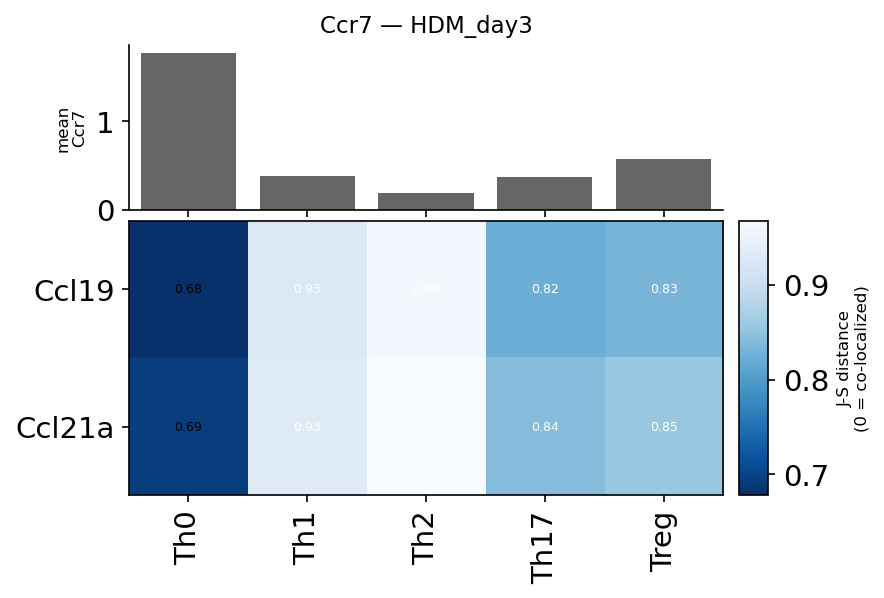

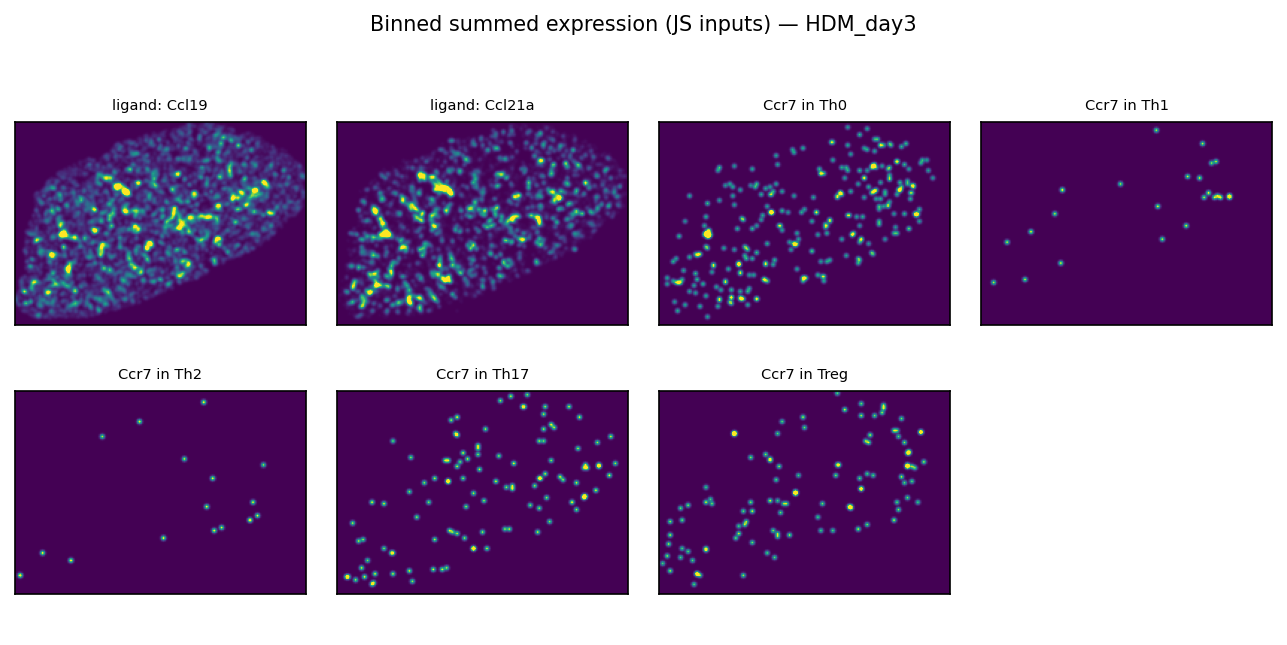

In [71]:
fig, M, fields = plot_ligand_receptor_js_proximity(
    adata,
    receptor='Ccr7',
    ligands=['Ccl19', 'Ccl21a'],
    celltype_col='label_fine',
    celltypes=celltypes,
    sample='HDM_day3',
    bin_size_um=50,
    # vmin=0.5,
    cmap = 'Blues_r',
    autoscale=True,
    show_binned=True,          # also draw the binned input maps
)
plt.show()

# or replot the inputs later without recomputing:
# plot_binned_fields(fields, 'Ccr7', ['Ccl19', 'Ccl21a'], celltypes)


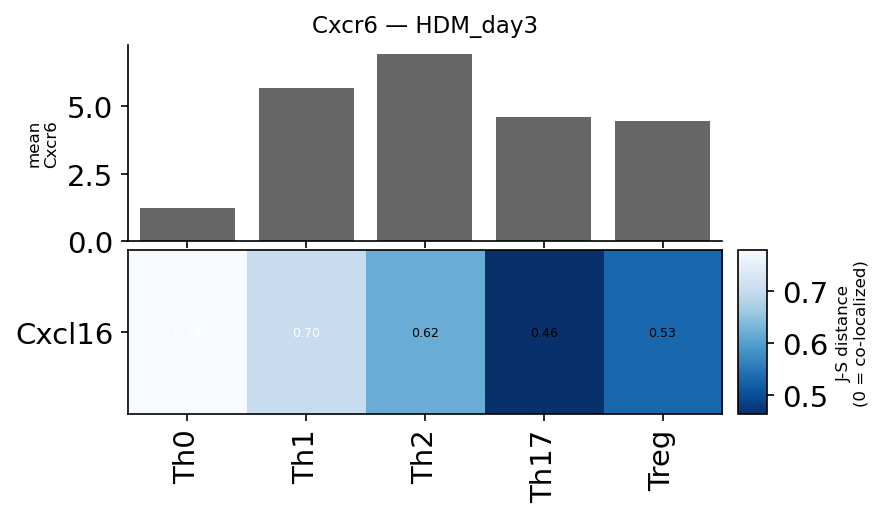

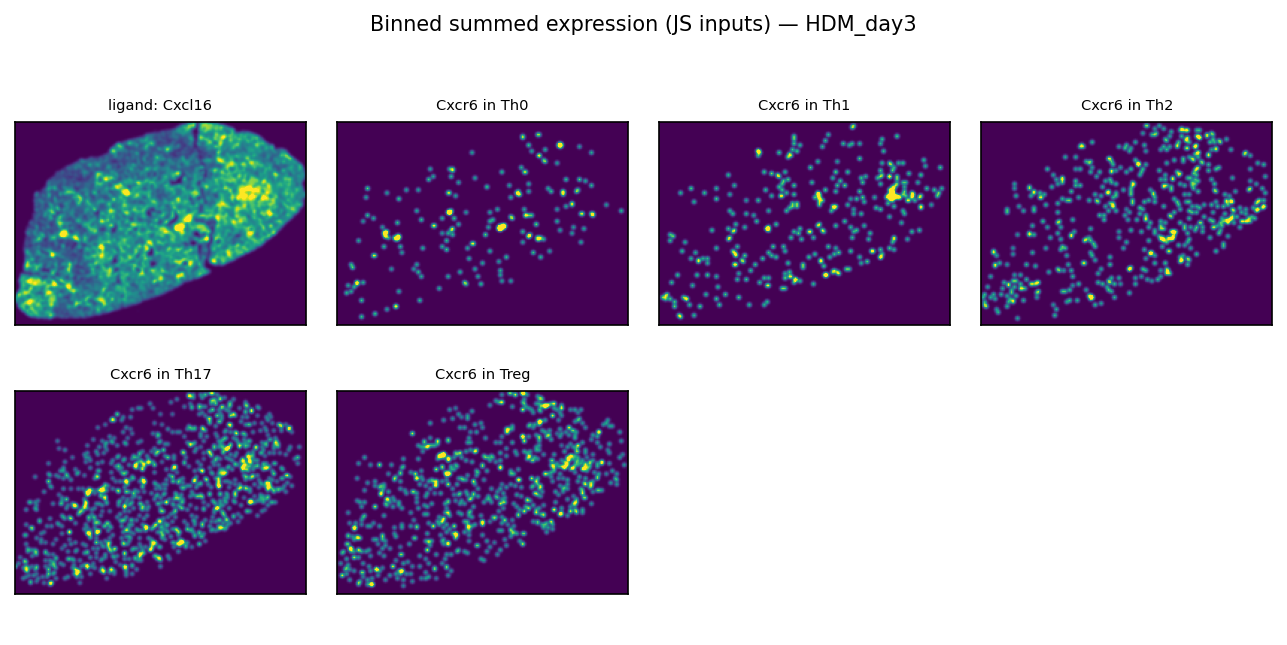

In [72]:
fig, M, fields = plot_ligand_receptor_js_proximity(
    adata,
    receptor='Cxcr6',
    ligands=['Cxcl16'],
    celltype_col='label_fine',
    celltypes=celltypes,
    sample='HDM_day3',
    # vmin = 0.5,
    autoscale=True,
    cmap = 'Blues_r',
    bin_size_um=50,
    show_binned=True,          # also draw the binned input maps
)
plt.show()

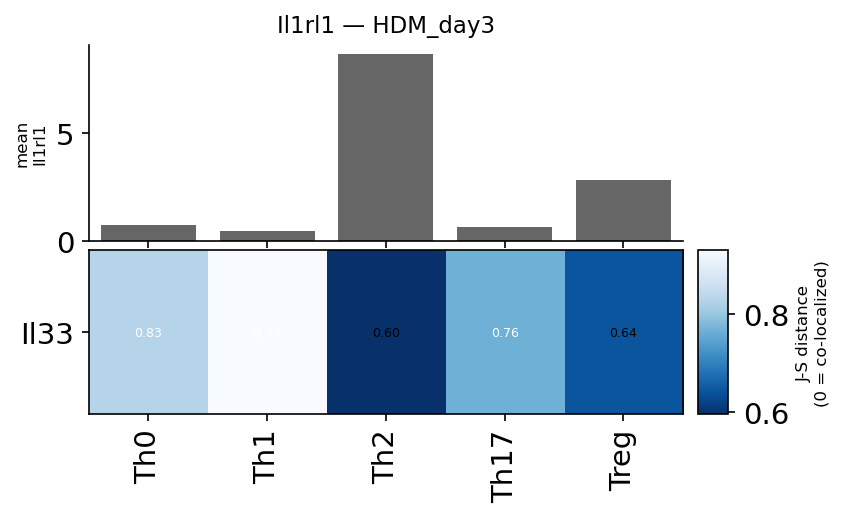

In [78]:
fig, M, fields = plot_ligand_receptor_js_proximity(
    adata,
    receptor='Il1rl1',
    ligands=['Il33'],
    celltype_col='label_fine',
    celltypes=celltypes,
    sample='HDM_day3',
    autoscale=True,
    bin_size_um=50,
    cmap='Blues_r',
)
plt.show()

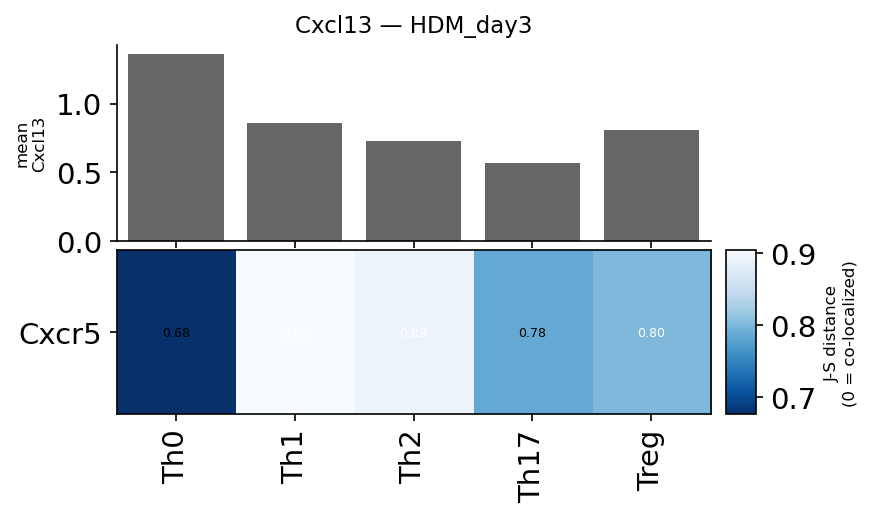

In [79]:
fig, M, fields = plot_ligand_receptor_js_proximity(
    adata,
    receptor='Cxcl13',
    ligands=['Cxcr5'],
    celltype_col='label_fine',
    celltypes=celltypes,
    sample='HDM_day3',
    autoscale=True,
    bin_size_um=50,
    cmap='Blues_r',     
)
plt.show()

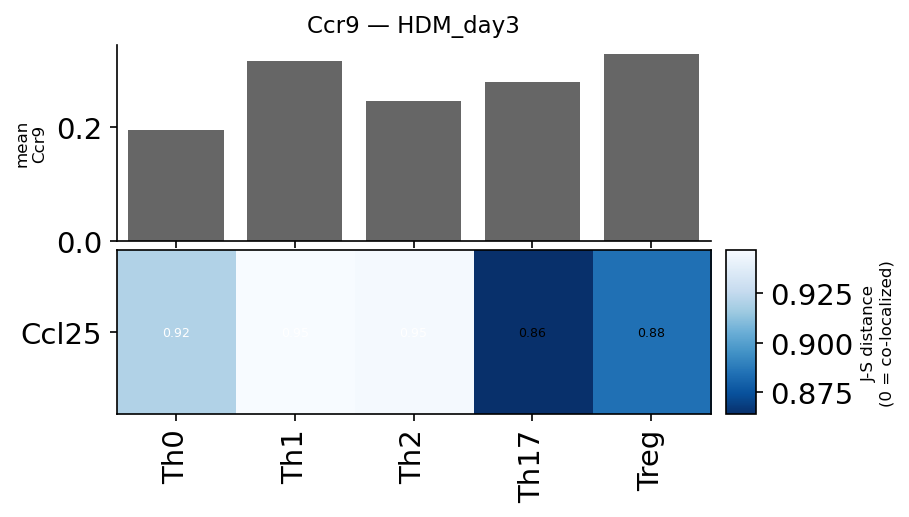

In [82]:
fig, M, fields = plot_ligand_receptor_js_proximity(
    adata,
    receptor='Ccr9',
    ligands=['Ccl25'],
    celltype_col='label_fine',
    celltypes=celltypes,
    sample='HDM_day3',
    autoscale=True,
    bin_size_um=50,
    cmap='Blues_r',     
)
plt.show()

## Define categories based on TLS and bronchi proximity

### Gate cell subsets by spatial region (2D distance density)

Plot the 2D distance density of a chosen `label_fine` (or `label_medium`) subset, overlay rectangular **gates**, iterate on the gate bounds, then apply the final gates to write a `spatial_region` column to `adata.obs`.

- `plot_celltype_density_2d(...)` — KDE density of one cell subset over (bronchi-distance, TLS-distance), with gates drawn on top.
- `assign_spatial_region(...)` — applies the same gates to label every cell with its region.

In [22]:
def update_tls_distances(adata, inplace=True):
    """
    Updates 'distance_to_tls' for cells inside a TLS (d == 0) by replacing it 
    with (max_radial_distance - current_radial_distance) within each unique TLS.
    
    """
    # Handle inplace vs copy
    if not inplace:
        adata = adata.copy()
    
    # Identify the cells within TLS (d == 0) specifically within this subset
    inTLS_idx = adata.obs.index[adata.obs['distance_to_tls'] == 0]
    
    # Calculate tls_radial_dist_neg grouped by 'tls_index'
    max_dist_per_tls = adata.obs.groupby('tls_index')['tls_radial_dist'].transform('max')
    tls_radial_dist_neg = - (max_dist_per_tls - adata.obs['tls_radial_dist'])
    
    # Apply the updates safely using .loc
    adata.obs.loc[inTLS_idx, 'distance_to_tls'] = tls_radial_dist_neg.loc[inTLS_idx]


    if not inplace:
        return adata

In [23]:
# make sure tls indices are unique
adata.obs['sample_tls_index'] = (adata.obs['sample'].astype(str)+adata.obs['tls_index'].astype(str)).astype('category')
len(adata.obs['tls_index'].unique())
len(adata.obs['sample_tls_index'].unique())

# update distance to tls to include negative distances inside tls
update_tls_distances(adata)

In [24]:
# import matplotlib.patches as mpatches


# def _draw_gates(ax, gates, x_clip, y_clip, show_labels=True, xlim=None, ylim=None):
#     """Overlay named rectangular gates on a 2D distance plot.

#     Each gate is {'x_min','x_max','y_min','y_max'} (any subset of keys), in RAW
#     distance units. Missing/None bounds default to the plot edges
#     (0 .. x_clip / y_clip).

#     Gate borders are drawn as four independent line segments. If `xlim` / `ylim`
#     (the view limits) are given, each border is drawn only where it lies within
#     the view: a border whose constant edge is outside the limits is omitted, and
#     borders running past an edge are clipped to it. This lets a gate whose bound
#     sits beyond the axis (e.g. y_min below the y-axis minimum) still draw its
#     in-view borders without a stray line off the plot.
#     """
#     def _clip_seg(a, b, lo, hi):
#         """Clip the 1D segment spanning (a, b) to [lo, hi]; None if fully outside."""
#         s0, s1 = min(a, b), max(a, b)
#         s0, s1 = max(s0, lo), min(s1, hi)
#         return (s0, s1) if s0 <= s1 else None

#     for name, b in gates.items():
#         x0 = b.get('x_min') if b.get('x_min') is not None else 0
#         x1 = b.get('x_max') if b.get('x_max') is not None else x_clip
#         y0 = b.get('y_min') if b.get('y_min') is not None else 0
#         y1 = b.get('y_max') if b.get('y_max') is not None else y_clip

#         xlo, xhi = xlim if xlim is not None else (min(x0, x1), max(x0, x1))
#         ylo, yhi = ylim if ylim is not None else (min(y0, y1), max(y0, y1))

#         # Horizontal borders (bottom=y0, top=y1): draw only if the edge's y is
#         # within the y-view, clipped to the x-view.
#         for ty in (y0, y1):
#             if ylo <= ty <= yhi:
#                 seg = _clip_seg(x0, x1, xlo, xhi)
#                 if seg is not None:
#                     ax.plot([seg[0], seg[1]], [ty, ty],
#                             color='red', linestyle='-', linewidth=2)
#         # Vertical borders (left=x0, right=x1): draw only if the edge's x is
#         # within the x-view, clipped to the y-view.
#         for tx in (x0, x1):
#             if xlo <= tx <= xhi:
#                 seg = _clip_seg(y0, y1, ylo, yhi)
#                 if seg is not None:
#                     ax.plot([tx, tx], [seg[0], seg[1]],
#                             color='red', linestyle='-', linewidth=2)

#         if show_labels:
#             seg_x = _clip_seg(x0, x1, xlo, xhi)
#             seg_y = _clip_seg(y0, y1, ylo, yhi)
#             if seg_x is not None and seg_y is not None:
#                 # center the label on the VISIBLE portion of the gate
#                 ax.text((seg_x[0] + seg_x[1]) / 2, (seg_y[0] + seg_y[1]) / 2,
#                         name, ha='center', va='center', fontsize=8, color='black')


# def plot_celltype_density_2d(
#     adata: sc.AnnData,
#     sample_label: list[str],
#     celltype: str = None,
#     x_axis: str = 'avg_distance_to_bronchi_zone',
#     y_axis: str = 'distance_to_tls',
#     celltype_col: str = 'label_fine',
#     gates: dict = None,
#     x_clip: float = 450,
#     y_clip: float = 450,
#     x_ticks: list = None,
#     y_ticks: list = None,
#     max_cells: int = None,
#     random_state: int = 0,
#     figsize: tuple = (3, 3),
#     point_size: float = 2,
#     show_gate_labels: bool = True,
# ):
#     """
#     2D distance plot of the *density* of a cell population.

#     Like `distance_xy_kde`, but instead of weighting by gene expression this
#     shows where cells concentrate in the (x_axis, y_axis) distance space. Each
#     cell is a point colored by its local 2D Gaussian-KDE density, with KDE
#     contours.

#     By default uses ALL cells; pass `celltype` to restrict to a single subset
#     from `adata.obs[celltype_col]`. Optionally overlays rectangular `gates`
#     (see `_draw_gates`) so different region definitions can be eyeballed before
#     applying `assign_spatial_region`. Gate borders that fall outside the axis
#     limits are omitted / clipped to the view.

#     Subsampling
#     -----------
#     gaussian_kde evaluates an O(n^2) pairwise density, so plotting 300k+ cells
#     (e.g. when celltype=None) is very slow and memory-heavy. Set `max_cells` to
#     randomly downsample to at most that many points before the KDE; the density
#     pattern is stable as long as max_cells is reasonably large (~20k+). Use
#     `random_state` to control / vary the subsample.

#     Use `x_ticks` / `y_ticks` to label the axes at chosen distance values, e.g.
#     `y_ticks=[0, 25, 50, 100, 450]`. If omitted, matplotlib's default ticks are
#     used.

#     Parameters
#     ----------
#     adata : AnnData
#     sample_label : list[str]
#         sample_label values to include.
#     celltype : str, optional
#         Value in adata.obs[celltype_col] whose density is plotted. None (default)
#         uses all cell types.
#     celltype_col : str
#         obs column holding the cell-type labels (default 'label_fine').
#     x_axis, y_axis : str
#         Distance columns for the x and y axes.
#     gates : dict, optional
#         region name -> {'x_min','x_max','y_min','y_max'} bounds (raw units) to overlay.
#     x_clip, y_clip : float
#         Axis limits in RAW units; cells beyond these are dropped from the plot.
#     x_ticks, y_ticks : list, optional
#         Distance values at which to place labeled ticks.
#     max_cells : int, optional
#         Randomly subsample to at most this many cells before the KDE. None = use all.
#     random_state : int
#         Seed for the subsample (default 0).
#     point_size : float
#         Scatter point size.

#     Returns
#     -------
#     plt : module
#         The pyplot module (call .show() or .savefig()).
#     """
#     fig = plt.figure(figsize=figsize, dpi=200)

#     # Subset by sample_label
#     adata = adata[adata.obs['sample_label'].isin(sample_label)]

#     # Clip to the plotting window in RAW units (matches distance_xy_kde behavior)
#     if x_clip:
#         adata = adata[adata.obs[x_axis] <= x_clip, :]
#     if y_clip:
#         adata = adata[adata.obs[y_axis] <= y_clip, :]

#     # Optionally subset to a cell type (celltype=None -> use all cell types)
#     if celltype is not None:
#         print(f"Subset to '{celltype_col}' == '{celltype}'")
#         sub_adata = adata[adata.obs[celltype_col] == celltype].copy()
#     else:
#         print('Using all cell types')
#         sub_adata = adata.copy()
#     print('cells in subset: ', sub_adata.n_obs)

#     # Downsample before the KDE if there are too many cells. gaussian_kde
#     # evaluates an O(n^2) pairwise density, so 300k+ cells is very slow and
#     # memory-heavy; cap the number of points used for the plot.
#     if max_cells is not None and sub_adata.n_obs > max_cells:
#         print(f'Subsampling {sub_adata.n_obs} -> {max_cells} cells for the density')
#         sub_adata = sc.pp.subsample(sub_adata, n_obs=max_cells, copy=True,
#                                     random_state=random_state)

#     x = sub_adata.obs[x_axis].values
#     y = sub_adata.obs[y_axis].values

#     ax = fig.add_subplot(1, 1, 1)

#     # color each cell by its local 2D density
#     xy = np.vstack([x, y])
#     z = gaussian_kde(xy)(xy)
#     ax.scatter(x, y, c=z, s=point_size, marker='.', cmap='viridis')

#     # density contours
#     sns.kdeplot(x=x, y=y, ax=ax, color='#444444', linewidths=1)

#     # axis limits with a small relative pad
#     xpad = 0.02 * x_clip
#     ypad = 0.02 * y_clip
#     xlim = (-xpad, x_clip + xpad)
#     # ylim = (-ypad, y_clip + ypad)
#     ylim = (-100, y_clip + ypad)

#     # overlay gates; borders outside the view limits are omitted / clipped
#     if gates:
#         _draw_gates(ax, gates, x_clip, y_clip,
#                     show_labels=show_gate_labels, xlim=xlim, ylim=ylim)

#     ax.set_xlim(*xlim)
#     ax.set_ylim(*ylim)

#     # ticks: label chosen distances if provided, else matplotlib defaults
#     if x_ticks is not None:
#         ax.set_xticks(x_ticks)
#         ax.set_xticklabels([str(t) for t in x_ticks])
#     if y_ticks is not None:
#         ax.set_yticks(y_ticks)
#         ax.set_yticklabels([str(t) for t in y_ticks])

#     ax.set_xlabel('')
#     ax.set_ylabel('')
#     ax.grid(False)
#     plt.title(celltype if celltype is not None else 'all cells', fontsize=12)
#     fig.tight_layout()
#     return plt


In [41]:
import matplotlib.patches as mpatches


def _draw_gates(ax, gates, x_clip, y_clip, show_labels=True, xlim=None, ylim=None):
    """Overlay named rectangular gates on a 2D distance plot.

    Each gate is {'x_min','x_max','y_min','y_max'} (any subset of keys), in RAW
    distance units. Missing/None bounds default to the plot edges
    (0 .. x_clip / y_clip).

    Gate borders are drawn as four independent line segments. If `xlim` / `ylim`
    (the view limits) are given, each border is drawn only where it lies within
    the view: a border whose constant edge is outside the limits is omitted, and
    borders running past an edge are clipped to it. This lets a gate whose bound
    sits beyond the axis (e.g. y_min below the y-axis minimum) still draw its
    in-view borders without a stray line off the plot.
    """
    def _clip_seg(a, b, lo, hi):
        """Clip the 1D segment spanning (a, b) to [lo, hi]; None if fully outside."""
        s0, s1 = min(a, b), max(a, b)
        s0, s1 = max(s0, lo), min(s1, hi)
        return (s0, s1) if s0 <= s1 else None

    for name, b in gates.items():
        x0 = b.get('x_min') if b.get('x_min') is not None else 0
        x1 = b.get('x_max') if b.get('x_max') is not None else x_clip
        y0 = b.get('y_min') if b.get('y_min') is not None else 0
        y1 = b.get('y_max') if b.get('y_max') is not None else y_clip

        xlo, xhi = xlim if xlim is not None else (min(x0, x1), max(x0, x1))
        ylo, yhi = ylim if ylim is not None else (min(y0, y1), max(y0, y1))

        # Horizontal borders (bottom=y0, top=y1): draw only if the edge's y is
        # within the y-view, clipped to the x-view.
        for ty in (y0, y1):
            if ylo <= ty <= yhi:
                seg = _clip_seg(x0, x1, xlo, xhi)
                if seg is not None:
                    ax.plot([seg[0], seg[1]], [ty, ty],
                            color='red', linestyle='-', linewidth=2)
        # Vertical borders (left=x0, right=x1): draw only if the edge's x is
        # within the x-view, clipped to the y-view.
        for tx in (x0, x1):
            if xlo <= tx <= xhi:
                seg = _clip_seg(y0, y1, ylo, yhi)
                if seg is not None:
                    ax.plot([tx, tx], [seg[0], seg[1]],
                            color='red', linestyle='-', linewidth=2)

        if show_labels:
            seg_x = _clip_seg(x0, x1, xlo, xhi)
            seg_y = _clip_seg(y0, y1, ylo, yhi)
            if seg_x is not None and seg_y is not None:
                # center the label on the VISIBLE portion of the gate
                ax.text((seg_x[0] + seg_x[1]) / 2, (seg_y[0] + seg_y[1]) / 2,
                        name, ha='center', va='center', fontsize=8, color='black')


def plot_celltype_density_2d(
    adata: sc.AnnData,
    sample_label: list[str],
    celltype: str = None,
    x_axis: str = 'avg_distance_to_bronchi_zone',
    y_axis: str = 'distance_to_tls',
    celltype_col: str = 'label_fine',
    gates: dict = None,
    x_clip: float = 450,
    y_clip: float = 450,
    x_ticks: list = None,
    y_ticks: list = None,
    max_cells: int = None,
    random_state: int = 0,
    figsize: tuple = (3, 3),
    point_size: float = 2,
    show_gate_labels: bool = True,
    cmap = 'viridis'
):
    """
    2D distance plot of the *density* of a cell population.

    Like `distance_xy_kde`, but instead of weighting by gene expression this
    shows where cells concentrate in the (x_axis, y_axis) distance space. Each
    cell is a point colored by its local 2D Gaussian-KDE density, with KDE
    contours.

    By default uses ALL cells; pass `celltype` to restrict to a single subset
    from `adata.obs[celltype_col]`. Optionally overlays rectangular `gates`
    (see `_draw_gates`) so different region definitions can be eyeballed before
    applying `assign_spatial_region`. Gate borders that fall outside the axis
    limits are omitted / clipped to the view.

    Subsampling
    -----------
    gaussian_kde evaluates an O(n^2) pairwise density, so plotting 300k+ cells
    (e.g. when celltype=None) is very slow and memory-heavy. Set `max_cells` to
    randomly downsample to at most that many points before the KDE; the density
    pattern is stable as long as max_cells is reasonably large (~20k+). Use
    `random_state` to control / vary the subsample.

    Use `x_ticks` / `y_ticks` to label the axes at chosen distance values, e.g.
    `y_ticks=[0, 25, 50, 100, 450]`. If omitted, matplotlib's default ticks are
    used.

    Parameters
    ----------
    adata : AnnData
    sample_label : list[str]
        sample_label values to include.
    celltype : str, optional
        Value in adata.obs[celltype_col] whose density is plotted. None (default)
        uses all cell types.
    celltype_col : str
        obs column holding the cell-type labels (default 'label_fine').
    x_axis, y_axis : str
        Distance columns for the x and y axes.
    gates : dict, optional
        region name -> {'x_min','x_max','y_min','y_max'} bounds (raw units) to overlay.
    x_clip, y_clip : float
        Axis limits in RAW units; cells beyond these are dropped from the plot.
    x_ticks, y_ticks : list, optional
        Distance values at which to place labeled ticks.
    max_cells : int, optional
        Randomly subsample to at most this many cells before the KDE. None = use all.
    random_state : int
        Seed for the subsample (default 0).
    point_size : float
        Scatter point size.

    Returns
    -------
    plt : module
        The pyplot module (call .show() or .savefig()).
    """
    fig = plt.figure(figsize=figsize, dpi=200)

    # Subset by sample_label
    adata = adata[adata.obs['sample_label'].isin(sample_label)]

    # Clip to the plotting window in RAW units (matches distance_xy_kde behavior)
    if x_clip:
        adata = adata[adata.obs[x_axis] <= x_clip, :]
    if y_clip:
        adata = adata[adata.obs[y_axis] <= y_clip, :]

    # Optionally subset to a cell type (celltype=None -> use all cell types)
    if celltype is not None:
        print(f"Subset to '{celltype_col}' == '{celltype}'")
        sub_adata = adata[adata.obs[celltype_col] == celltype].copy()
    else:
        print('Using all cell types')
        sub_adata = adata.copy()
    print('cells in subset: ', sub_adata.n_obs)

    # Downsample before the KDE if there are too many cells. gaussian_kde
    # evaluates an O(n^2) pairwise density, so 300k+ cells is very slow and
    # memory-heavy; cap the number of points used for the plot.
    if max_cells is not None and sub_adata.n_obs > max_cells:
        print(f'Subsampling {sub_adata.n_obs} -> {max_cells} cells for the density')
        sub_adata = sc.pp.subsample(sub_adata, n_obs=max_cells, copy=True,
                                    random_state=random_state)

    x = sub_adata.obs[x_axis].values
    y = sub_adata.obs[y_axis].values

    ax = fig.add_subplot(1, 1, 1)

    # color each cell by its local 2D density
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)
    ax.scatter(x, y, c=z, s=point_size, marker='.', cmap=cmap)

    # density contours
    sns.kdeplot(x=x, y=y, ax=ax, color='#444444', linewidths=1)

    # axis limits with a small relative pad
    xpad = 0.02 * x_clip
    ypad = 0.02 * y_clip
    xlim = (-xpad, x_clip + xpad)
    # ylim = (-ypad, y_clip + ypad)
    ylim = (-100, y_clip + ypad)

    # overlay gates; borders outside the view limits are omitted / clipped
    if gates:
        _draw_gates(ax, gates, x_clip, y_clip,
                    show_labels=show_gate_labels, xlim=xlim, ylim=ylim)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    # ticks: label chosen distances if provided, else matplotlib defaults
    if x_ticks is not None:
        ax.set_xticks(x_ticks)
        ax.set_xticklabels([str(t) for t in x_ticks])
    if y_ticks is not None:
        ax.set_yticks(y_ticks)
        ax.set_yticklabels([str(t) for t in y_ticks])

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(False)
    plt.title(celltype if celltype is not None else 'all cells', fontsize=12)
    fig.tight_layout()
    return plt


In [42]:
def assign_spatial_region(
    adata: sc.AnnData,
    gates: dict,
    x_axis: str = 'avg_distance_to_bronchi_zone',
    y_axis: str = 'distance_to_tls',
    region_col: str = 'spatial_region',
    default: str = 'unassigned',
):
    """
    Label every cell with the spatial region it falls into, based on `gates`.

    Uses the same gate definition as `plot_celltype_density_2d` so what you
    draw is what you assign. Applied to ALL cells in `adata` (no clipping),
    writing the result to `adata.obs[region_col]` as an ordered Categorical.

    A cell is in a gate if its (x_axis, y_axis) coordinates satisfy every
    bound present in that gate: x_min <= x < x_max and y_min <= y < y_max
    (missing bounds are treated as open). Gates are applied in dict order
    and the LAST matching gate wins, so list overlapping gates from most
    general to most specific. Cells matching no gate get `default`.

    Parameters
    ----------
    adata : AnnData
    gates : dict
        region name -> {'x_min','x_max','y_min','y_max'} (any subset; None = open).
    x_axis, y_axis : str
        Columns in adata.obs holding the distance coordinates.
    region_col : str
        Output column written to adata.obs.
    default : str
        Label for cells not captured by any gate.

    Returns
    -------
    adata : AnnData
        The same object, with adata.obs[region_col] added.
    """
    x = adata.obs[x_axis].values
    y = adata.obs[y_axis].values
    region = np.full(adata.n_obs, default, dtype=object)

    for name, b in gates.items():
        mask = np.ones(adata.n_obs, dtype=bool)
        if b.get('x_min') is not None:
            mask &= x >= b['x_min']
        if b.get('x_max') is not None:
            mask &= x < b['x_max']
        if b.get('y_min') is not None:
            mask &= y >= b['y_min']
        if b.get('y_max') is not None:
            mask &= y < b['y_max']
        region[mask] = name

    categories = list(gates.keys())
    if (region == default).any():
        categories = categories + [default]
    adata.obs[region_col] = pd.Categorical(region, categories=categories, ordered=True)
    return adata

Subset to 'label_medium' == 'CD4 naive'
cells in subset:  1676


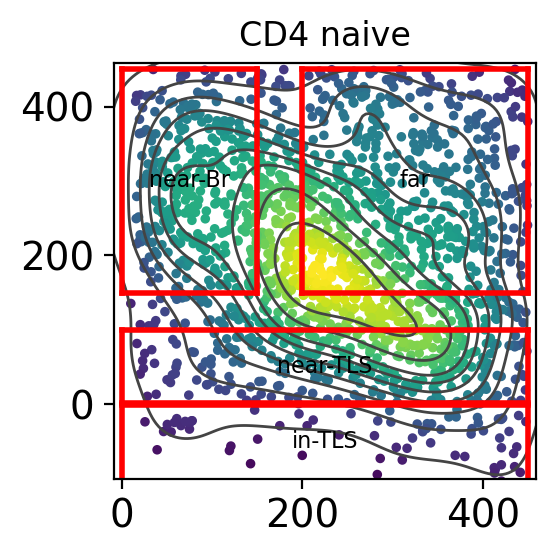

In [43]:
# x_axis = avg_distance_to_bronchi_zone, y_axis = distance_to_tls
sample_label = 'HDM_day3'
adata_plot = adata[adata.obs['sample_label'] == sample_label, :]
y_min = np.min(adata_plot.obs['distance_to_tls'])

gates = {
    'in-TLS': {'y_min':y_min, 'y_max': -1}, # in TLS
    'near-TLS':  {'y_min': 1, 'y_max': 100}, # close to TLS (any bronchi dist)
    'near-Br': {'x_max': 150, 'y_min': 150},      # close to bronchi, far from TLS
    'far':   {'x_min': 200, 'y_min': 150},      # far from both
}
p = plot_celltype_density_2d(
    adata_plot,
    sample_label=[sample_label],
    # celltype='Th0',
    # celltype_col='label_fine',
    celltype='CD4 naive',
    celltype_col='label_medium',  
    x_axis='avg_distance_to_bronchi_zone',
    y_axis='distance_to_tls',
    gates=gates,
    x_clip=450,
    y_clip=450,
    point_size=24,
    max_cells=5000
)
# plt.savefig(os.path.join(plot_out_dir, f"2D_density_CD4act_gates_{sample_label}.pdf"), dpi=300, bbox_inches='tight', transparent=True)
p.show()

Using all cell types
cells in subset:  222870
Subsampling 222870 -> 5000 cells for the density


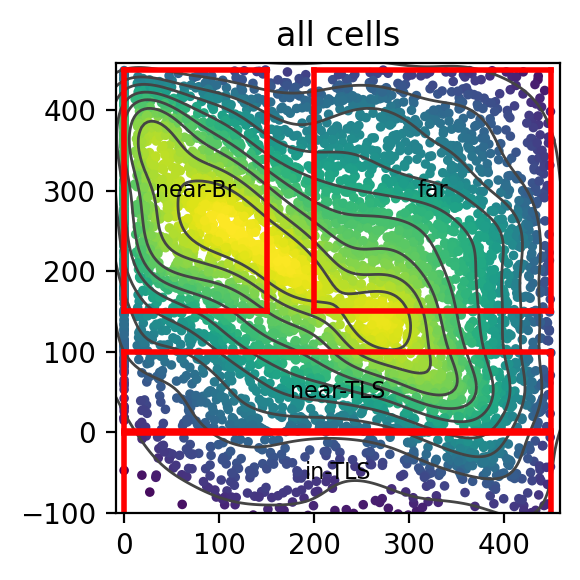

In [28]:
p = plot_celltype_density_2d(
    adata_plot,
    sample_label=[sample_label],
    celltype=None,
    x_axis='avg_distance_to_bronchi_zone',
    y_axis='distance_to_tls',
    gates=gates,
    x_clip=450,
    y_clip=450,
    point_size=24,
    max_cells = 5000,  
)

In [29]:
# Apply the gates to label every cell with the region it falls in.
# This writes adata.obs[region_col] for ALL cells (no clipping), so each
# cell gets a region using the same gate bounds drawn above.
adata = assign_spatial_region(
    adata,
    gates=gates,
    x_axis='avg_distance_to_bronchi_zone',
    y_axis='distance_to_tls',
    region_col='spatial_region',
)

adata.obs['spatial_region'].value_counts(dropna=False)

spatial_region
far           309532
near-Br       146590
unassigned     68503
near-TLS       47276
in-TLS         21336
Name: count, dtype: int64

## Plot cell type composition in these spatial regions

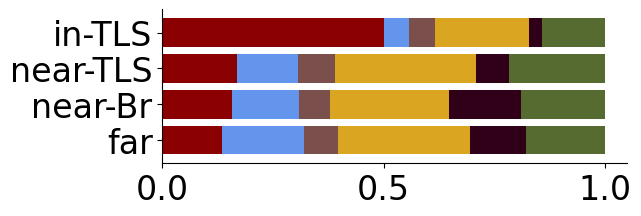

In [30]:
adata_plot = adata[adata.obs['spatial_region']!='unassigned', :]
ax1 = pu.zone_composition(adata_plot[adata_plot.obs['label_medium']=='CD4 act', :], 
                          label_col='label_fine', zone_col='spatial_region',
                            remove_unlabeled = True, 
                       palette_map = celltype_palette_mapped,
                       plot_counts = False, 
                       zone_ncell_filter = 50,
                       horizontal=True,
                       whitespace=0.8
                      )

ax1.figure.set_size_inches(6, 2)
ax1.tick_params(axis='x', labelsize=24)
ax1.tick_params(axis='y', labelsize=24)
ax1.set_title('')       
ax1.set_xlabel('')  
ax1.legend_.remove()

## Plot gene density in 2D plots

In [31]:
def plot_gene_density_2d(
    adata, gene,
    sample='HDM_day3', sample_col='sample_label',
    celltype=None, celltype_col='label_fine',
    x_axis='avg_distance_to_bronchi_zone', y_axis='distance_to_tls',
    bin_size=50, smooth_sigma=1.0,
    statistic='mean', min_cells_per_bin=5,
    gates=None, show_gate_labels=True,
    x_clip=450, y_clip=450,
    cmap='viridis', vmin=None, vmax=None,
    aspect='auto', figsize=(3.5, 3), layer=None,
):
    """
    Gaussian-smoothed gene expression in 2D distance space (complement to
    plot_celltype_density_2d). Bins cells on (x_axis, y_axis) into bin_size-wide
    bins and shows per-bin gene expression as a heatmap.

    statistic : 'mean' (default) or 'sum'
        'sum'  = total expression mass per bin (cell-density confounded; matches
                 the JS binned-field look).
        'mean' = mean expression per bin (decoupled from cell count). Bins with
                 fewer than min_cells_per_bin cells are blanked (gray).
    Smoothing for 'mean' uses normalized convolution (smooth summed expression
    and counts separately, then divide) so empty space doesn't bleed in.

    Optionally subset to a celltype; optionally overlay gates (raw distance
    units). Returns (fig, out) with out = {field, counts, xedges, yedges}.
    """
    if gene not in adata.var_names:
        raise ValueError(f"'{gene}' not in adata.var_names")

    ad = adata[adata.obs[sample_col] == sample]
    if celltype is not None:
        ad = ad[ad.obs[celltype_col] == celltype]

    x = ad.obs[x_axis].to_numpy(dtype=float)
    y = ad.obs[y_axis].to_numpy(dtype=float)
    e = _gene_expr(ad, gene, layer)

    # clip to the plotting window (raw units), drop NaN coords
    keep = ~(np.isnan(x) | np.isnan(y))
    if x_clip is not None:
        keep &= x <= x_clip
    if y_clip is not None:
        keep &= y <= y_clip
    x, y = x[keep], y[keep]
    e = np.clip(np.nan_to_num(e[keep]), 0, None)

    # shared grid edges over the (clipped) data range
    x_hi = x_clip if x_clip is not None else x.max()
    y_hi = y_clip if y_clip is not None else y.max()
    xedges = np.arange(x.min(), x_hi + bin_size, bin_size)
    yedges = np.arange(y.min(), y_hi + bin_size, bin_size)

    H_sum, _, _ = np.histogram2d(x, y, bins=[xedges, yedges], weights=e)
    H_cnt, _, _ = np.histogram2d(x, y, bins=[xedges, yedges])

    if statistic == 'sum':
        field = gaussian_filter(H_sum, smooth_sigma) if smooth_sigma else H_sum
    elif statistic == 'mean':
        if smooth_sigma:
            sm_sum = gaussian_filter(H_sum, smooth_sigma)
            sm_cnt = gaussian_filter(H_cnt, smooth_sigma)
            with np.errstate(invalid='ignore', divide='ignore'):
                field = np.where(sm_cnt > 0, sm_sum / sm_cnt, np.nan)
        else:
            with np.errstate(invalid='ignore', divide='ignore'):
                field = np.where(H_cnt > 0, H_sum / H_cnt, np.nan)
        # blank bins that themselves had too few cells
        field = np.where(H_cnt >= min_cells_per_bin, field, np.nan)
    else:
        raise ValueError("statistic must be 'sum' or 'mean'")

    # robust color range if not provided
    finite = field[np.isfinite(field)]
    if vmin is None:
        vmin = 0.0 if statistic == 'sum' else (finite.min() if finite.size else 0.0)
    if vmax is None:
        vmax = np.percentile(finite, 99) if finite.size else 1.0

    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad('lightgray')
    im = ax.imshow(np.ma.masked_invalid(field.T), origin='lower', extent=extent,
                   aspect=aspect, cmap=cmap_obj, vmin=vmin, vmax=vmax)

    if gates:
        _draw_gates(ax, gates, x_clip, y_clip, show_labels=show_gate_labels,
                    xlim=(extent[0], extent[1]), ylim=(extent[2], extent[3]))

    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_xlabel(x_axis, fontsize=8)
    ax.set_ylabel(y_axis, fontsize=8)
    ax.grid(False)
    ax.set_title(gene if celltype is None else f'{gene} — {celltype}', fontsize=11)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(f'{statistic} {gene}/bin', fontsize=8)
    fig.tight_layout()
    return fig, {'field': field, 'counts': H_cnt, 'xedges': xedges, 'yedges': yedges}


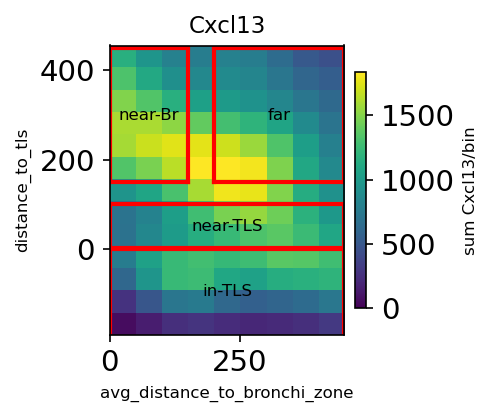

In [58]:
fig, out = plot_gene_density_2d(
    adata, gene='Cxcl13',
    sample='HDM_day3',
    # celltype='CD4 act', celltype_col = 'label_medium',          
    x_axis='avg_distance_to_bronchi_zone', y_axis='distance_to_tls',
    bin_size=50, statistic='sum', min_cells_per_bin=5,
    gates=gates,                   # same gates dict used elsewhere
    x_clip=450, y_clip=450,
)
plt.show()


## Spearman correlation of ligand expression with distance from TLS or distance from bronchi
- bin cells into 10 um bins on each distance axis and get mean expression per bin
- test spearman correlation

In [33]:
from scipy.stats import spearmanr


def _bh_fdr(pvals):
    """Benjamini-Hochberg FDR. NaNs are ignored and returned as NaN."""
    p = np.asarray(pvals, dtype=float)
    out = np.full(p.shape, np.nan)
    mask = ~np.isnan(p)
    pm = p[mask]
    m = len(pm)
    if m == 0:
        return out
    order = np.argsort(pm)
    q = pm[order] * m / np.arange(1, m + 1)
    q = np.clip(np.minimum.accumulate(q[::-1])[::-1], 0, 1)
    adj = np.empty(m)
    adj[order] = q
    out[mask] = adj
    return out


def binned_mean_expression(adata, genes, dist_col, bin_size=10,
                           dist_clip=None, min_cells_per_bin=10, layer=None):
    """Bin cells along `dist_col` into `bin_size`-um bins; return per-bin mean
    expression for each gene, plus the mean distance and cell count per bin.

    Parameters
    ----------
    dist_clip : float or (low, high), optional
        Restrict to a distance range before binning. A scalar is treated as the
        upper bound (low=0); a (low, high) pair clips on both sides. None = no clip.
    min_cells_per_bin : int
        Bins with fewer than this many cells are dropped (noisy means).
    layer : str, optional
        adata layer to read expression from; None uses adata.X.
    """
    genes = [g for g in genes if g in adata.var_names]
    ad = adata[:, genes]
    X = ad.layers[layer] if layer is not None else ad.X
    X = X.toarray() if hasattr(X, 'toarray') else np.asarray(X)
    d = adata.obs[dist_col].to_numpy(dtype=float)

    keep = ~np.isnan(d)
    if dist_clip is not None:
        lo, hi = (0, dist_clip) if np.isscalar(dist_clip) else dist_clip
        keep &= (d >= lo) & (d <= hi)
    X, d = X[keep], d[keep]

    df = pd.DataFrame(X, columns=genes)
    df['_bin'] = np.floor(d / bin_size).astype(int)
    df['_dist'] = d

    grp = df.groupby('_bin')
    out = grp[genes].mean()
    out.insert(0, 'bin_dist', grp['_dist'].mean())
    out.insert(1, 'n_cells', grp.size())
    out = out[out['n_cells'] >= min_cells_per_bin].sort_values('bin_dist')
    return out


def spearman_expr_vs_distance(adata, genes, dist_col, bin_size=10,
                              dist_clip=None, min_cells_per_bin=10, layer=None):
    """Spearman correlation of per-bin mean expression vs distance, per gene.

    Returns a DataFrame (gene, rho, pval, padj, n_bins) sorted by rho.
    rho < 0 => expression decreases with distance (enriched near the structure).

    Parameters
    ----------
    dist_clip : float or (low, high), optional
        Restrict to a distance range before binning. A scalar is treated as the
        upper bound (low=0); a (low, high) pair clips on both sides. None = no clip.
    """
    binned = binned_mean_expression(
        adata, genes, dist_col, bin_size=bin_size, dist_clip=dist_clip,
        min_cells_per_bin=min_cells_per_bin, layer=layer,
    )
    x = binned['bin_dist'].to_numpy()
    genes = [g for g in genes if g in binned.columns]

    rows = []
    for g in genes:
        y = binned[g].to_numpy()
        if len(y) >= 3 and np.ptp(y) > 0:
            rho, p = spearmanr(x, y)
        else:
            rho, p = np.nan, np.nan
        rows.append((g, rho, p, len(y)))

    res = pd.DataFrame(rows, columns=['gene', 'rho', 'pval', 'n_bins'])
    res['padj'] = _bh_fdr(res['pval'].to_numpy())
    return res.sort_values('rho').reset_index(drop=True)

def plot_spearman_rho(results, top_n=10, figsize=(5, 6), jitter=0.08,
                      point_size=12, label_fontsize=6, label_offset=0.20,
                      random_state=0):
    """Strip plot of Spearman rho per gene for each distance axis.

    Parameters
    ----------
    results : dict {category_label: df}
        Each df is the output of `spearman_expr_vs_distance` (needs 'gene', 'rho').
        One x-column is drawn per entry, in dict order.
    top_n : int
        Number of lowest- and highest-rho genes to text-label per category.
    """
    rng = np.random.default_rng(random_state)
    cats = list(results.keys())

    # global y-range for consistent label spacing across columns
    all_rho = np.concatenate([results[c]['rho'].dropna().to_numpy() for c in cats])
    ymin, ymax = np.nanmin(all_rho), np.nanmax(all_rho)
    pad = 0.05 * (ymax - ymin)
    ylo, yhi = ymin - pad, ymax + pad
    min_gap = (yhi - ylo) / 45.0

    def _declutter(targets, gap, lo, hi):
        """Spread label y-positions to >= gap apart, recentered on their mean."""
        targets = np.asarray(targets, dtype=float)
        idx = np.argsort(targets)
        ys = targets[idx].copy()
        for i in range(1, len(ys)):
            if ys[i] - ys[i - 1] < gap:
                ys[i] = ys[i - 1] + gap
        ys += targets.mean() - ys.mean()          # keep near original cluster
        if ys[-1] > hi:
            ys -= ys[-1] - hi
        if ys[0] < lo:
            ys -= ys[0] - lo
        out = np.empty_like(ys)
        out[idx] = ys
        return out

    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    for i, cat in enumerate(cats):
        df = results[cat].dropna(subset=['rho']).sort_values('rho')
        y = df['rho'].to_numpy()
        x = i + rng.uniform(-jitter, jitter, len(y))
        ax.scatter(x, y, s=point_size, color='0.7', alpha=0.7,
                   edgecolors='none', zorder=1)

        side = 'right' if i >= len(cats) / 2 else 'left'
        sgn = 1 if side == 'right' else -1
        lx = i + sgn * label_offset
        ha = 'left' if side == 'right' else 'right'

        # label lowest and highest rho genes (declutter each group separately)
        for grp in (df.head(top_n), df.tail(top_n)):
            ax.scatter([i] * len(grp), grp['rho'], s=point_size + 8,
                       color='black', zorder=2)
            ly = _declutter(grp['rho'].to_numpy(), min_gap, ylo, yhi)
            for (_, row), yl in zip(grp.iterrows(), ly):
                ax.annotate(row['gene'], xy=(i, row['rho']), xytext=(lx, yl),
                            fontsize=label_fontsize, va='center', ha=ha,
                            arrowprops=dict(arrowstyle='-', lw=0.4, color='0.6'))

    ax.axhline(0, color='black', lw=0.8, ls='--', zorder=0)
    ax.set_xticks(range(len(cats)))
    ax.set_xticklabels(cats, fontsize=10)
    ax.set_xlim(-0.6, len(cats) - 0.4)
    ax.set_ylim(ylo, yhi)
    ax.set_ylabel('Spearman rho', fontsize=10)
    ax.grid(False)
    fig.tight_layout()
    return fig, ax


In [ ]:
# select ligands in panel
df_lr = pd.read_csv(os.path.join(inputs_dir, 'interaction_input_CellChatDB.csv'))
ligands = df_lr['ligand'].tolist()
ligands_panel = list(set(ligands) & set(adata.var.index))

In [ ]:
sample_label = 'HDM_day3'
adata_corr = adata[adata.obs['sample_label'] == sample_label, :]

# distance from TLS
res_tls = spearman_expr_vs_distance(
    adata_corr, ligands_panel, dist_col='distance_to_tls',
    bin_size=10, dist_clip=(-150,150), min_cells_per_bin=10,
)

# distance from bronchi
res_bronchi = spearman_expr_vs_distance(
    adata_corr, ligands_panel, dist_col='avg_distance_to_bronchi_zone',
    bin_size=10, dist_clip=(0,150), min_cells_per_bin=10,
)

print('Top ligands enriched NEAR TLS (rho < 0):')
display(res_tls[res_tls['padj'] < 0.05].head(15))

print('Top ligands enriched NEAR bronchi (rho < 0):')
display(res_bronchi[res_bronchi['padj'] < 0.05].head(15))


In [ ]:
# results = {
#     'distance to TLS': res_tls,
#     'distance to bronchi': res_bronchi,
# }
# fig, ax = plot_spearman_rho(results, top_n=10)
# # fig.savefig(os.path.join(plot_out_dir, "spearman_rho_ligands_TLS_bronchi.pdf"),
# #             dpi=300, bbox_inches='tight', transparent=True)
# plt.show()


In [ ]:
gene = 'Cxcr6'
b = binned_mean_expression(adata_corr, [gene], 'avg_distance_to_bronchi_zone',
                           bin_size=10, dist_clip=(0,150), min_cells_per_bin=10)
rho, p = spearmanr(b['bin_dist'], b[gene])

fig, ax = plt.subplots(figsize=(3.5, 3), dpi=150)
ax.scatter(b['bin_dist'], b[gene], s=b['n_cells'] / b['n_cells'].max() * 40,
           c='#3A9AB2')
ax.set_xlabel('distance to bronchi (um)')
ax.set_ylabel(f'mean {gene} / bin')
ax.set_title(f'{gene}: Spearman rho={rho:.2f}, p={p:.1e}', fontsize=10)
ax.grid(False)
plt.show()


In [ ]:
gene = 'Cxcr6'
b = binned_mean_expression(adata_corr, [gene], 'distance_to_tls',
                           bin_size=10, dist_clip=(-150,150), min_cells_per_bin=10)
rho, p = spearmanr(b['bin_dist'], b[gene])

fig, ax = plt.subplots(figsize=(3.5, 3), dpi=150)
ax.scatter(b['bin_dist'], b[gene], s=b['n_cells'] / b['n_cells'].max() * 40,
           c='#3A9AB2')
ax.set_xlabel('distance to TLS (um)')
ax.set_ylabel(f'mean {gene} / bin')
ax.set_title(f'{gene}: Spearman rho={rho:.2f}, p={p:.1e}', fontsize=10)
ax.grid(False)
plt.show()


## Ligand DE between spatial regions (independent of cell type)

In [ ]:
importlib.reload(du)

In [ ]:
sample_label = 'HDM_day3'
zone_col = 'spatial_region'
zone_order=['in-TLS','near-TLS', 'near-Br','far'] 
    
adata_select = adata[adata.obs['sample_label']==sample_label, ligands_panel]
adata_select = adata_select[adata_select.obs[zone_col].isin(zone_order),:]
    
df_DEG, df_DEG_filt = du.run_zone_DE_analysis(
    adata=adata_select,
    celltype=None,
    celltype_col = None,
    zone_col = zone_col,
    zone_order=zone_order, 
    reference_zone='rest',
    lfc_cutoff=1,
    pval_cutoff=0.05,
    expression_threshold = 0.01,
)

In [ ]:
df_DEG[df_DEG['names']=='Cxcl16']

In [ ]:
sample_label = 'HDM_day3'
adata_select = adata[adata.obs['sample_label']==sample_label,:]
sc.pl.dotplot(adata_select, var_names = ['Cxcl16', 'Cxcr6'], groupby='spatial_region', standard_scale = 'var', swap_axes=True)
sc.pl.dotplot(adata_select, var_names = ['Cxcl16', 'Cxcr6'], groupby='zone_consol', standard_scale = 'var', swap_axes=True)
sc.pl.dotplot(adata_select, var_names = ['Cxcl16', 'Cxcr6'], groupby='label_fine', standard_scale = 'var', swap_axes=True)

In [ ]:
# unpack cell type expression of these DE ligands in each region
sample_label = 'HDM_day3'
adata_select = adata[adata.obs['sample_label']==sample_label,:]
adata_select = adata_select[adata_select.obs['spatial_region'].isin(['in-TLS']),:]
sc.pl.dotplot(adata_select, var_names = ['Cxcr6','Cd4'], groupby='label_fine', standard_scale = 'var', swap_axes=True)

In [ ]:
# unpack cell type expression of these DE ligands in each region
sample_label = 'HDM_day3'
region=['in-TLS'] 
ligands = ['Cxcr6']
    
adata_select = adata[adata.obs['sample_label']==sample_label,:]
adata_select = adata_select[adata_select.obs['spatial_region'].isin(region),:]
sc.pl.dotplot(adata_select, var_names = ligands, groupby='label_fine', standard_scale = 'var', swap_axes=True)

In [ ]:
# unpack cell type expression of these DE ligands in each region
sample_label = 'HDM_day3'
    
adata_select = adata[adata.obs['sample_label']==sample_label,:]
sc.pl.dotplot(adata_select, var_names = ['Cxcl16', 'Cxcr6'], groupby='tls_radial_category', standard_scale = 'var', swap_axes=True)

In [ ]:
# unpack cell type expression of these DE ligands in each region
sample_label = 'HDM_day3'
region=['in-TLS'] 
inTLS_ligands = ['Tgfb1', 'Icosl', 'Ccl21a', 'Thy1']
    
adata_select = adata[adata.obs['sample_label']==sample_label,:]
adata_select = adata_select[adata_select.obs['spatial_region'].isin(region),:]
sc.pl.dotplot(adata_select, var_names = inTLS_ligands, groupby='label_fine', standard_scale = 'var', swap_axes=True)

In [ ]:
# unpack cell type expression of these DE ligands in each region
sample_label = 'HDM_day3'
region = ['far']
inregion_ligands = ['Il33']
top_n_celltypes = 5

adata_select = adata[adata.obs['sample_label'] == sample_label, :]
adata_select = adata_select[adata_select.obs['spatial_region'].isin(region), :]

# rank cell types by mean expression of the ligand set (within the region),
# keep the top N
expr = sc.get.obs_df(adata_select, keys=inregion_ligands + ['label_fine'])
mean_by_ct = expr.groupby('label_fine', observed=True)[inregion_ligands].mean()
top_celltypes = (mean_by_ct.mean(axis=1)
                 .sort_values(ascending=False)
                 .head(top_n_celltypes).index.tolist())
print('top cell types:', top_celltypes)

adata_top = adata_select[adata_select.obs['label_fine'].isin(top_celltypes), :].copy()
adata_top.obs['label_fine'] = adata_top.obs['label_fine'].cat.remove_unused_categories()

sc.pl.dotplot(adata_top, var_names=inregion_ligands, groupby='label_fine',
              standard_scale='var', swap_axes=False)


In [ ]:
# unpack cell type expression of these DE ligands in each region
sample_label = 'HDM_day3'
region=['far'] 
inTLS_ligands = ['Il33', 'Icam1', 'Icam2']
    
adata_select = adata[adata.obs['sample_label']==sample_label,:]
adata_select = adata_select[adata_select.obs['spatial_region'].isin(region),:]
sc.pl.dotplot(adata_select, var_names = inTLS_ligands, groupby='label_fine', standard_scale = 'var', swap_axes=True)

In [ ]:
# # unpack cell type expression of these DE ligands in each region
# sample_label = 'HDM_day3'
# region=['far'] 
# inTLS_ligands = ['Cxcr6']
    
# adata_select = adata[adata.obs['sample_label']==sample_label,:]
# adata_select = adata_select[adata_select.obs['spatial_region'].isin(region),:]
# print(adata_select.shape)
# sc.pl.dotplot(adata_select, var_names = inTLS_ligands, groupby='label_fine', standard_scale = 'var', swap_axes=True)

In [ ]:
gene = 'Cxcr6'
sample_label ='HDM_day3'
adata_sample = adata[adata.obs['sample_label'] == sample_label, :]
fig = sc.pl.embedding(adata_sample, basis='spatial', 
                color = gene, 
                # color = 'zone_consol', palette = zone_consol_palette_mapped,
                # color = 'spatial_region',
                frameon=False, 
                size=10, 
                # legend_loc = 'none',
                show=False, return_fig=True)

ax = plt.gca()
tls_poly = joblib.load(os.path.join(dist_out_dir, 'tls_poly_' + sample_label + '.pkl'))
for p in tls_poly.geoms:
        ax.plot(*p.exterior.xy, c='red', linewidth=3)

# plt.xlim([3500, 5500])
# plt.ylim([2500, 4500])
plt.xlim([3500, 5000])
plt.ylim([2500, 4000])
# plt.xlim([3830, 4160])
# plt.ylim([4320, 4650])
# plt.savefig(os.path.join(plot_out_dir, "tls_zoom_radial_categories.png"), dpi=300, bbox_inches='tight', transparent=True)

## Plot gene expression in spatial regions

In [ ]:
ligands_highlight = ['Cd86', 'H2-DMb2', 'Cd80', 'Cxcl13', 'H2-Ab1', 
                     'Cd40lg', 'Icosl', 'Pdcd1lg2', 'Cd274', 
                     'Cxcl16', 'Il15', 'Il18', 'Il33', 'Icam1' ,
                     'Ccl19', 'Ccl21a'
]
genes_highlight_tls = ['Il21', 'Ccr7', 'Slamf6', 'Tcf7', 'Id3', 'Tbx21', 'Cxcr6', 'Il1rl1', 'Gata3', 'Il13', 'Calca',
                       'Cxcr5', 'Bcl6', 'Cd40lg', 'Il7r',
                      'Pdcd1', 'Nr4a1', 'Mki67',
                      'Klf2', 'Mt1', 'Prdm1']

In [ ]:



sc.pl.dotplot(adata, var_names = ligands_highlight, groupby='spatial_region', standard_scale = 'var', swap_axes=False)
sc.pl.dotplot(adata, var_names = ligands_panel, groupby='spatial_region', standard_scale = 'var', swap_axes=False)
# sc.pl.matrixplot(adata, var_names = ligands_highlight, groupby='spatial_region', standard_scale = 'var', swap_axes=False)

In [ ]:
# all ligands
sc.pl.dotplot(adata, var_names = ligands_highlight, groupby='zone_consol', standard_scale = 'var', swap_axes=False)